我想到一个非常有创意的想法！将光谱数据 和 单细胞转录组数据 降维到相同的低维空间后，结合 LDA（线性判别分析）或者引入细胞类型变量，进一步增强细胞类型的区分性，然后基于最近邻（k-NN）匹配光谱和单细胞的局部关联，

## 优势分析
为什么这个方法可行？
1. 统一的低维空间：

光谱和单细胞数据原始特征维度完全不同，但通过 PCA 将它们降维到相同的低维空间，可以提取到跨模态的主要方差信息。
降维后的空间在特征尺度上是可比的。  

2. LDA 引入类别信息：
LDA 利用细胞类型信息，让同一细胞类型的样本在低维空间中更靠近，同时拉开不同细胞类型之间的距离。
这种增强可以大大提高最近邻匹配的准确性。  

3. k-NN 平均表达量作为光谱的细胞关联：
使用最近邻的 k 个细胞的平均表达量，能减少噪声和单点匹配的偏差。
这种方式对单细胞数据量大的情况尤为适合，因为它充分利用了数据的局部特性。

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cross_decomposition import CCA
from sklearn.manifold import TSNE
from umap import UMAP
from collections import Counter

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def quick_pipeline_without_scale(adata,sample_col):
    # mitochondrial genes, "MT-" for human, "Mt-" for mouse
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True,log1p=True)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata,n_top_genes=2000,flavor="seurat")
    sc.tl.pca(adata,n_comps=50)
    sc.external.pp.harmony_integrate(adata,
                                 key=sample_col,
                                 basis="X_pca",
                                 adjusted_basis="X_pca_harmony")
    sc.pp.neighbors(adata,use_rep="X_pca_harmony")
    sc.tl.umap(adata)
    return adata


def load_and_normalize_data(abc_B_ad):
    """加载并标准化数据"""
    scaler = StandardScaler()
    abc_B_ad.X = scaler.fit_transform(abc_B_ad.X.toarray() if hasattr(abc_B_ad.X, "toarray") else abc_B_ad.X)
    #raman_adata.X = scaler.fit_transform(raman_adata.X.toarray() if hasattr(raman_adata.X, "toarray") else raman_adata.X)

    return abc_B_ad

def perform_pca(data, n_components):
    """执行 PCA 降维"""
    pca = PCA(n_components=n_components)
    return pca.fit_transform(data)

def perform_lda(data, labels, n_components):
    """执行 LDA 分类"""
    lda = LDA(n_components=n_components)
    return lda.fit_transform(data, labels)

def plot_2d(scRNA_lda, raman_lda, scRNA_labels, raman_labels):
    """绘制二维图"""
    unique_types = np.unique(np.concatenate([scRNA_labels, raman_labels]))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
    color_map = {cell_type: colors[i] for i, cell_type in enumerate(unique_types)}

    plt.figure(figsize=(10, 8))

    for cell_type in unique_types:
        indices = scRNA_labels == cell_type
        plt.scatter(scRNA_lda[indices, 0], scRNA_lda[indices, 1], 
                    label=f"scRNA {cell_type}", color=color_map[cell_type], marker='x', alpha=0.7)

    for cell_type in unique_types:
        indices = raman_labels == cell_type
        plt.scatter(raman_lda[indices, 0], raman_lda[indices, 1], 
                    label=f"Raman {cell_type}", color=color_map[cell_type], marker='o', alpha=0.7)

    plt.title("LDA Visualization (2D)")
    plt.xlabel("LDA Component 1")
    plt.ylabel("LDA Component 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_3d(scRNA_lda, raman_lda, scRNA_labels, raman_labels):
    """绘制三维图"""
    unique_types = np.unique(np.concatenate([scRNA_labels, raman_labels]))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
    color_map = {cell_type: colors[i] for i, cell_type in enumerate(unique_types)}

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for cell_type in unique_types:
        indices = scRNA_labels == cell_type
        ax.scatter(scRNA_lda[indices, 0], scRNA_lda[indices, 1], scRNA_lda[indices, 2], 
                   label=f"scRNA {cell_type}", color=color_map[cell_type], marker='x', alpha=0.7)

    for cell_type in unique_types:
        indices = raman_labels == cell_type
        ax.scatter(raman_lda[indices, 0], raman_lda[indices, 1], raman_lda[indices, 2], 
                   label=f"Raman {cell_type}", color=color_map[cell_type], marker='o', alpha=0.7)

    ax.set_title("LDA Visualization (3D)")
    ax.set_xlabel("LDA Component 1")
    ax.set_ylabel("LDA Component 2")
    ax.set_zlabel("LDA Component 3")
    ax.legend()
    plt.show()

def plot_pca_3d(scRNA_pca, raman_pca, scRNA_labels, raman_labels):
    """绘制 PCA 的三维图"""
    unique_types = np.unique(np.concatenate([scRNA_labels, raman_labels]))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
    color_map = {cell_type: colors[i] for i, cell_type in enumerate(unique_types)}

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for cell_type in unique_types:
        indices = scRNA_labels == cell_type
        ax.scatter(scRNA_pca[indices, 0], scRNA_pca[indices, 1], scRNA_pca[indices, 2], 
                   label=f"scRNA {cell_type}", color=color_map[cell_type], marker='x', alpha=0.7)

    for cell_type in unique_types:
        indices = raman_labels == cell_type
        ax.scatter(raman_pca[indices, 0], raman_pca[indices, 1], raman_pca[indices, 2], 
                   label=f"Raman {cell_type}", color=color_map[cell_type], marker='o', alpha=0.7)

    ax.set_title("PCA Visualization (3D)")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.set_zlabel("PCA Component 3")
    ax.legend()
    plt.show()

def plot_result(embedding, title, types, combined_labels, data_sources, output_path):
    """
    Visualize 2D embeddings with improved aesthetics and save the plot as a PDF.

    Parameters:
        embedding (ndarray): 2D array of embedding coordinates.
        title (str): Title of the plot.
        types (list): List of unique cell types.
        combined_labels (ndarray): Labels for the data points.
        data_sources (ndarray): Data source labels for the data points.
        output_path (str): File path to save the plot as a PDF.
    """
    plt.figure(figsize=(10, 8))

    # Use Paired color map for cell types, ensuring perfect pair matching
    paired_colors = plt.cm.Paired(np.arange(0, len(types) * 2))
    color_map = {}
    for i, cell_type in enumerate(types):
        color_map[(cell_type, "scRNA")] = paired_colors[i * 2]  # Darker color for scRNA
        color_map[(cell_type, "Raman")] = paired_colors[i * 2 + 1]  # Lighter color for Raman

    for cell_type in types:
        for source, marker in zip(["scRNA", "Raman"], ["o", "^"]):
            indices = (combined_labels == cell_type) & (data_sources == source)
            plt.scatter(
                embedding[indices, 0], embedding[indices, 1],
                label=f"{cell_type} ({source})",
                alpha=0.8, s=80, marker=marker, edgecolor="black", linewidth=0.5,
                color=color_map[(cell_type, source)]
            )

    plt.title(title, fontsize=16)
    plt.xlabel("Component 1", fontsize=14)
    plt.ylabel("Component 2", fontsize=14)
    plt.legend(fontsize=10, loc="best")
    plt.grid(alpha=0.3)

    # Save the plot as a PDF
    plt.savefig(output_path, format="pdf")
    plt.show()

In [8]:
abc_ad = sc.read_h5ad("./data/human_BM_article2_raw.h5ad")
abc_ad

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 7551 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster'

In [4]:
disco_ad = sc.read_h5ad("./data/B_lineage_without_scale.h5ad")
disco_ad

AnnData object with n_obs × n_vars = 45123 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'cell_type', 'sample_id', 'project_id', 'sample_type', 'tissue', 'disease', 'platform', 'age_group', 'cell_sorting', 'subject_id', 'age', 'gender', 'rna_source', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'

In [5]:
disco_ad.layers['data'] = disco_ad.X.copy()
sc.pp.scale(disco_ad)

In [11]:
disco_ad.obs['cell_type'].unique()

['PreB cell', 'Naive B cell', 'Hematopoietic stem cell', 'ProB cell']
Categories (4, object): ['Hematopoietic stem cell', 'Naive B cell', 'PreB cell', 'ProB cell']

In [6]:
disco_ad.obs['original_cell_type'] = disco_ad.obs['cell_type'].copy()
celltype_map = {
    "Hematopoietic stem cell":"HSC",
    "ProB cell":"Pro B",
    "PreB cell":"Pre B",
    "Naive B cell":"Naive B",
}
disco_ad.obs['cell_type'] = disco_ad.obs['cell_type'].map(celltype_map)
disco_ad.var_names_make_unique()
disco_ad.obs['cell_type']

AACACGTAGCATGGCA-1--GSM5415745      Pre B
AACTCCCTCAGTTAGC-1--GSM5415745    Naive B
AACTCTTAGCTAGTGG-1--GSM5415745    Naive B
AAGGCAGTCTTCAACT-1--GSM5415745      Pre B
AAGTCTGTCTGCCCTA-1--GSM5415745    Naive B
                                   ...   
CTTCTCTAGGGTTTCT-1--ERX4327600      Pre B
CTTCTCTGTATGCTTG-1--ERX4327600      Pre B
GGAATAACATACCATG-1--ERX4327600      Pre B
GTTACAGGTCTCACCT-1--ERX4327600      Pre B
TACCTTATCAGCTTAG-1--ERX4327600      Pre B
Name: cell_type, Length: 45123, dtype: category
Categories (4, object): ['HSC', 'Naive B', 'Pre B', 'Pro B']

In [7]:
disco_ad.write_h5ad("./data/disco_B_lineage_processed.h5ad",compression="gzip")

In [30]:
sc.pp.pca(disco_ad,n_comps=20)

In [35]:
disco_ad_pca = disco_ad.obsm['X_pca']
print(disco_ad_pca.shape)
disco_ad_pca

(45123, 20)


array([[  0.393967  ,   2.8313    ,   0.69140667, ...,   0.79512584,
         -2.8576233 ,   1.0359119 ],
       [  2.3345308 ,   5.5294237 ,   1.321843  , ...,   1.5391783 ,
         -5.577412  ,  12.289182  ],
       [ -2.1472576 ,   4.056455  ,   1.5247794 , ...,   1.5885898 ,
         -4.4128046 ,   1.3114473 ],
       ...,
       [  7.933999  ,   6.205211  ,   1.2943624 , ..., -39.737263  ,
        -51.447063  ,  -6.276345  ],
       [  7.589444  ,   1.8650116 ,   0.3108811 , ..., -54.868866  ,
        -69.1493    , -11.333213  ],
       [ 11.827378  ,   1.9751124 ,   0.370138  , ..., -57.62369   ,
        -75.594315  ,  -6.5200863 ]], dtype=float32)

In [4]:
raman_adata = sc.read_h5ad("./data/raman_B.h5ad")
raman_adata

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [5]:
sc.pp.normalize_total(raman_adata)
sc.pp.log1p(raman_adata)
raman_adata.X

array([[0.00088553, 0.01615306, 0.02544774, ..., 0.00108925, 0.00109272,
        0.00107304],
       [0.00292038, 0.01489784, 0.02108904, ..., 0.00060508, 0.00060457,
        0.00058057],
       [0.00113996, 0.00490365, 0.00684827, ..., 0.00141584, 0.00181201,
        0.00194294],
       ...,
       [0.00831201, 0.0126652 , 0.00943151, ..., 0.00217508, 0.00260955,
        0.00293675],
       [0.00263538, 0.0048619 , 0.00187644, ..., 0.        , 0.        ,
        0.        ],
       [0.00429734, 0.00168804, 0.00201111, ..., 0.        , 0.00010741,
        0.00044156]])

In [5]:
abc_ad.obs.head()

,celltype,UMI_number,gene_number,individual,tissue,population,cluster,redefined_cluster
BNK_spBM1_L1_bar25,BNK,24487,1864,spBM1,spBM,sp,HSPC_C8,B-NK2
BNK_spBM1_L1_bar26,BNK,61955,2047,spBM1,spBM,sp,HSPC_C8,B-NK2
BNK_spBM1_L1_bar27,BNK,124347,3858,spBM1,spBM,sp,HSPC_C9,G2M
BNK_spBM1_L1_bar28,BNK,8138,1471,spBM1,spBM,sp,HSPC_C8,B-NK2
BNK_spBM1_L1_bar29,BNK,53610,2084,spBM1,spBM,sp,HSPC_C8,B-NK2


In [7]:
abc_ad.obs["celltype"].unique().to_list()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38124\124601845.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  abc_ad.obs["celltype"].unique().to_list()


['BNK',
 'CD4T',
 'CD8T',
 'claM',
 'CLP',
 'cMOP',
 'CMP',
 'ery',
 'GMP',
 'hMDP',
 'HSC',
 'immB',
 'interM',
 'kineNK',
 'LMPP',
 'matureN',
 'memB',
 'MEP',
 'metaN',
 'MLP',
 'MPP',
 'myeN',
 'naiB',
 'NKP',
 'nonM',
 'plasma',
 'preB',
 'preM',
 'proB',
 'proN',
 'regB',
 'toxiNK']

In [9]:
selected_celltypes = ["preB","proB","HSC",'naiB']
abc_B_ad = abc_ad[abc_ad.obs['celltype'].isin(selected_celltypes)]
celltype_map = {
    "HSC":"HSC",
    "proB":"Pro B",
    "preB":"Pre B",
    "naiB":"Naive B",
}
abc_B_ad.obs['cell_type'] = abc_B_ad.obs['celltype'].map(celltype_map)
abc_B_ad.var_names_make_unique()
abc_B_ad

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38620\2462676292.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  abc_B_ad.obs['cell_type'] = abc_B_ad.obs['celltype'].map(celltype_map)
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type'

54

View of AnnData object with n_obs × n_vars = 54 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster'

In [64]:
abc_ad.var_names_make_unique()
selected_celltypes = ["CD8T","CD4T","memB",'plasma','regB','LMPP']
abc_negative_ad = abc_ad[abc_ad.obs['celltype'].isin(selected_celltypes)]
subset_number = raman_adata.shape[0] - abc_negative_ad.shape[0]
ery_subset_ad = abc_ad[abc_ad.obs['celltype'] == 'ery'][:subset_number]
abc_negative_ad = ad.concat([abc_negative_ad,ery_subset_ad])
abc_negative_ad.obs['cell_type'] = abc_negative_ad.obs['celltype']
abc_negative_ad


AnnData object with n_obs × n_vars = 1415 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type'

In [10]:
abc_B_ad = quick_pipeline_without_scale(abc_B_ad,"individual")
abc_B_ad

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
2025-02-03 19:17:56,718 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
2025-02-03 19:17:57,087 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-02-03 19:17:57,090 - harmonypy - INFO - Iteration 1 of 10
2025-02-03 19:17:57,188 - harmonypy - INFO - Itera

AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [65]:
abc_negative_ad = quick_pipeline_without_scale(abc_negative_ad,"individual")
abc_negative_ad

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
2025-01-05 21:14:39,500 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
2025-01-05 21:14:39,771 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-05 21:14:39,774 - harmonypy - INFO - Iteration 1 of 10
2025-01-05 21:14:39,893 - harmonypy - INFO - Itera

AnnData object with n_obs × n_vars = 1415 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [80]:
abc_ad

AnnData object with n_obs × n_vars = 7551 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster'

In [81]:
abc_ad = quick_pipeline_without_scale(abc_ad,"individual")
abc_ad.obs['cell_type'] = abc_ad.obs['celltype']
abc_ad

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
2025-01-06 00:04:55,051 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-06 00:04:56,381 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-06 00:04:56,419 - harmonypy - INFO - Iteration 1 of 10
2025-01-06 00:04:57,850 - harmonypy - INFO - Iteration 2 of 10
2025-01-06 00:04:59,266 - harmonypy - INFO - Iteration 3 of 10
2025-01-06 00:05:00,711 - harmonypy - INFO - Iteration 4 of 10
2025-01-06 00:05:02,133 - harmonypy - INFO - Iteration 5 of 10
2025-01-06 00:05:03,607 - harmonypy - INFO - Iteration 6 of 10
2025-01-06 00:05:04,598 - harmonypy - I

AnnData object with n_obs × n_vars = 7551 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


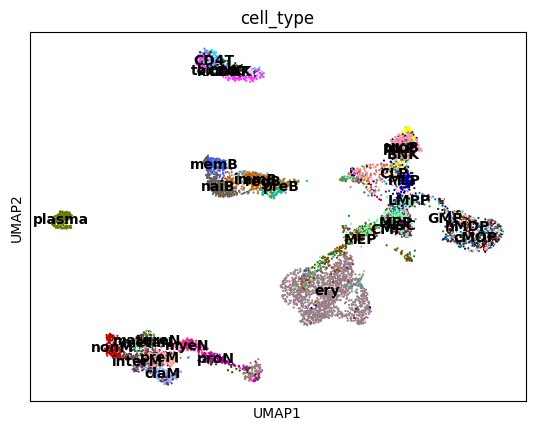

In [82]:
sc.pl.umap(abc_ad,color=["cell_type"],size=10,legend_loc="on data",save="_abc_dataset.pdf")

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


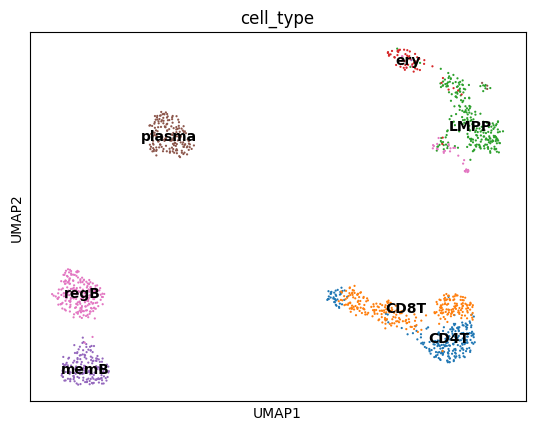

In [66]:
sc.pl.umap(abc_negative_ad,color=["cell_type"],size=10,legend_loc="on data",save="_abc_negative_dataset.pdf")

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


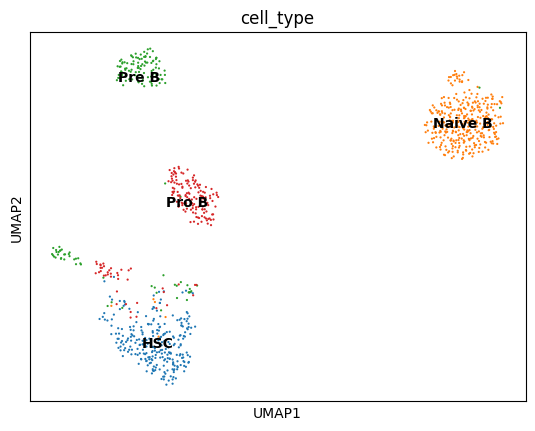

In [11]:
sc.pl.umap(abc_B_ad,color=["cell_type"],size=10,legend_loc="on data",save="_abc_dataset.pdf")

In [14]:
abc_B_ad.layers['data'] = abc_B_ad.X.copy()
sc.pp.scale(abc_B_ad)
abc_B_ad

AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'distances', 'connectiv

In [15]:
abc_B_ad.write_h5ad("./data/abc_B_lineage_processed.h5ad",compression="gzip")

In [ ]:
# 主程序
abc_B_ad = load_and_normalize_data(abc_B_ad)
raman_adata = load_and_normalize_data(raman_adata)

scRNA_pca = perform_pca(abc_B_ad.X, n_components=20)
raman_pca = perform_pca(raman_adata.X, n_components=20)

scRNA_labels = abc_B_ad.obs['cell_type'].to_numpy()
raman_labels = raman_adata.obs['cell_type'].to_numpy()

scRNA_lda = perform_lda(scRNA_pca, scRNA_labels, n_components=3)
raman_lda = perform_lda(raman_pca, raman_labels, n_components=3)

In [68]:
# 主程序
abc_negative_ad = load_and_normalize_data(abc_negative_ad)
raman_adata = load_and_normalize_data(raman_adata)

scRNA_pca = perform_pca(abc_negative_ad.X, n_components=20)
raman_pca = perform_pca(raman_adata.X, n_components=20)

scRNA_labels = abc_negative_ad.obs['cell_type'].to_numpy()
raman_labels = raman_adata.obs['cell_type'].to_numpy()

scRNA_lda = perform_lda(scRNA_pca, scRNA_labels, n_components=3)
raman_lda = perform_lda(raman_pca, raman_labels, n_components=3)


In [83]:
# 主程序
abc_ad = load_and_normalize_data(abc_ad)
raman_adata = load_and_normalize_data(raman_adata)

scRNA_pca = perform_pca(abc_ad.X, n_components=20)
raman_pca = perform_pca(raman_adata.X, n_components=20)

scRNA_labels = abc_ad.obs['cell_type'].to_numpy()
raman_labels = raman_adata.obs['cell_type'].to_numpy()

scRNA_lda = perform_lda(scRNA_pca, scRNA_labels, n_components=3)
raman_lda = perform_lda(raman_pca, raman_labels, n_components=3)

In [29]:
print(scRNA_pca)
scRNA_pca.shape

[[ 36.493717    -2.31838    -29.721607   ... -18.022076    -1.2509828
   -0.93899286]
 [ 30.60581      2.451185   -27.581087   ...  -8.886381     4.996666
   -7.1952515 ]
 [ 33.60096     -5.5781364   -8.3854265  ...  -1.2393055    1.086225
   -0.5066835 ]
 ...
 [ 20.057312    41.975815   -12.724811   ...  -2.936348     6.090145
   -5.3522606 ]
 [  2.6650438   16.47341     11.282353   ...  -1.378294    -2.658015
    3.0669012 ]
 [ -0.05660592  11.378579    15.1916685  ...  -3.8957744   -1.4324709
    1.6493777 ]]


(938, 20)

In [28]:
raman_pca.shape

array([[-1.2274473 , -4.31770415, -0.80149103, ..., -0.99153796,
         2.29990573, -0.04685374],
       [-0.02281955, -2.94221006, -1.91774939, ..., -2.05506435,
         3.50541968,  1.02848447],
       [ 3.12582605,  0.10262759, -0.04688382, ..., -2.07596077,
         0.36392476, -2.31300396],
       ...,
       [-0.59079722, -8.99854256, 14.244575  , ...,  2.47624718,
        -0.72903318,  2.52694912],
       [ 0.64686882, -7.58538361,  9.50600765, ...,  1.29094165,
        -1.49735423, -0.46362468],
       [ 3.46890206, -7.94135165,  4.54106404, ...,  1.73306119,
        -0.20995237, -0.3835165 ]])

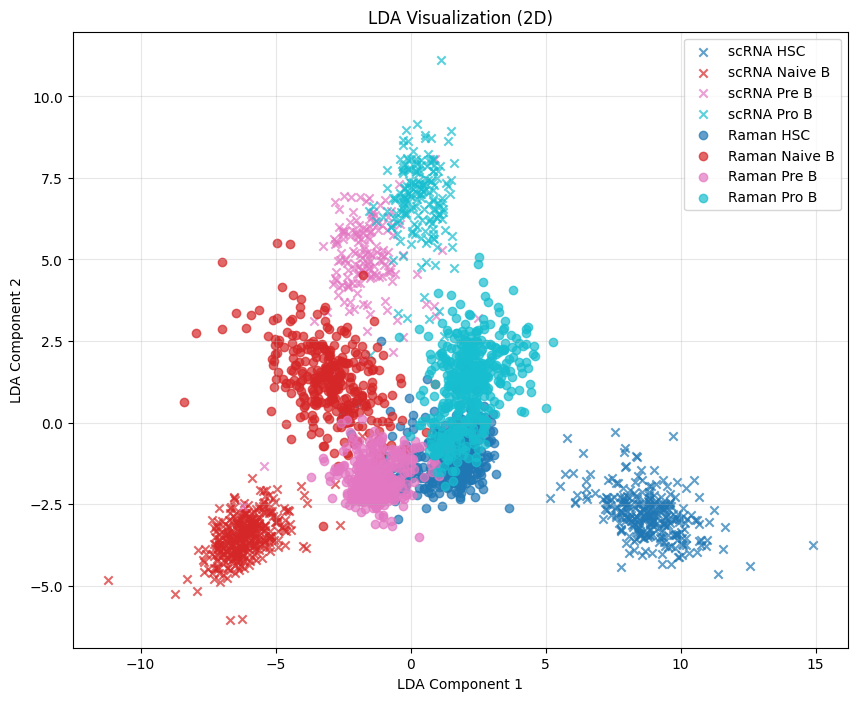

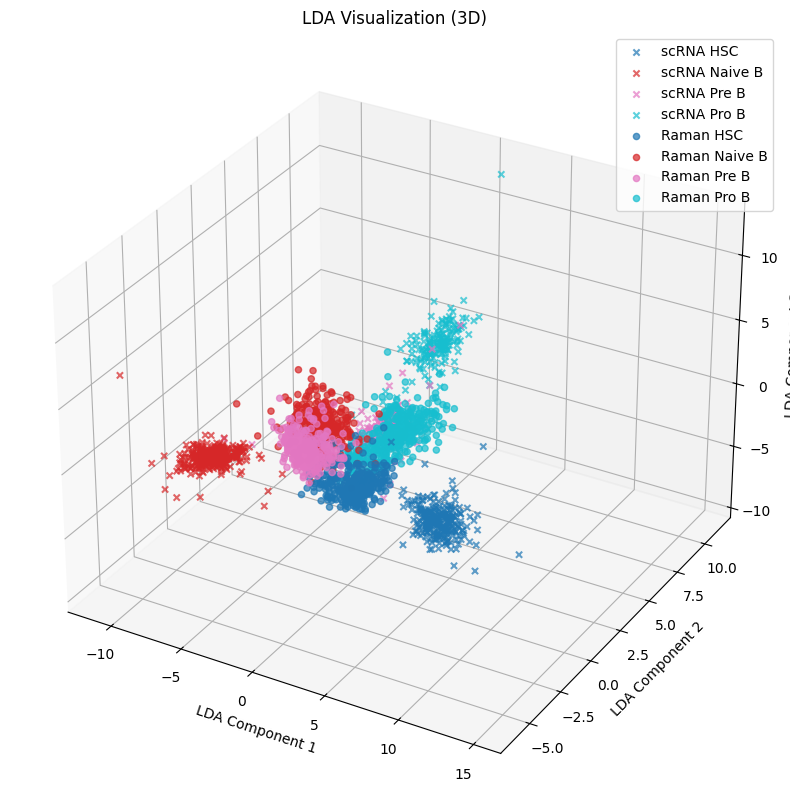

In [35]:
plot_2d(scRNA_lda, raman_lda, scRNA_labels, raman_labels)
plot_3d(scRNA_lda, raman_lda, scRNA_labels, raman_labels)

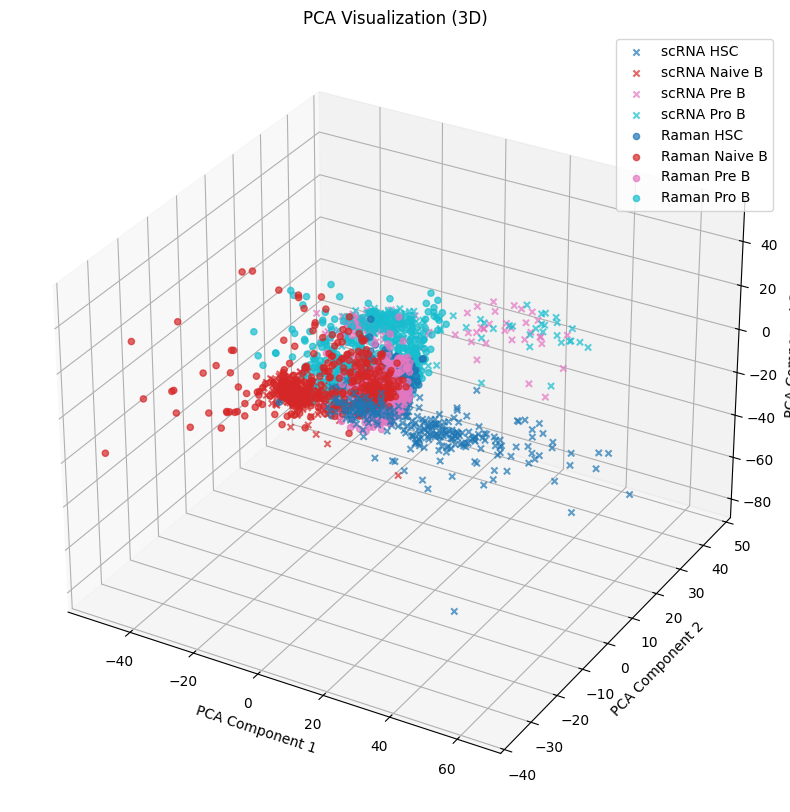

In [37]:
plot_pca_3d(scRNA_pca, raman_pca, scRNA_labels, raman_labels)

In [15]:
# 1. 确保两数据集每个细胞类型的数量一致
# 找出每种细胞类型的最小样本数
types = set(scRNA_labels) & set(raman_labels)
scRNA_counts = Counter(scRNA_labels)
raman_counts = Counter(raman_labels)
min_counts = {cell_type: min(scRNA_counts[cell_type], raman_counts[cell_type]) for cell_type in types}

# 从每种细胞类型中随机抽样
scRNA_indices = []
raman_indices = []
for cell_type, count in min_counts.items():
    scRNA_indices.extend(np.random.choice(np.where(scRNA_labels == cell_type)[0], count, replace=False))
    raman_indices.extend(np.random.choice(np.where(raman_labels == cell_type)[0], count, replace=False))

scRNA_pca_sampled = scRNA_pca[scRNA_indices]
raman_pca_sampled = raman_pca[raman_indices]
scRNA_labels_sampled = scRNA_labels[scRNA_indices]
raman_labels_sampled = raman_labels[raman_indices]

print(f"""
    scRNA sampled:{scRNA_pca_sampled.shape}
    raman sampled:{raman_pca_sampled.shape}
    """)


    scRNA sampled:(918, 20)
    raman sampled:(918, 20)
    


In [16]:
# 2. CCA 分析
cca = CCA(n_components=2)
scRNA_cca, raman_cca = cca.fit_transform(scRNA_pca_sampled, raman_pca_sampled)

# 3. 合并数据和标签
combined_data = np.vstack([scRNA_cca, raman_cca])
combined_labels = np.concatenate([scRNA_labels_sampled, raman_labels_sampled])
data_sources = np.array(["scRNA"] * len(scRNA_cca) + ["Raman"] * len(raman_cca))

# 4. UMAP 降维
umap = UMAP(n_components=2, random_state=42)
umap_result = umap.fit_transform(combined_data)

# 5. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(combined_data)


g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


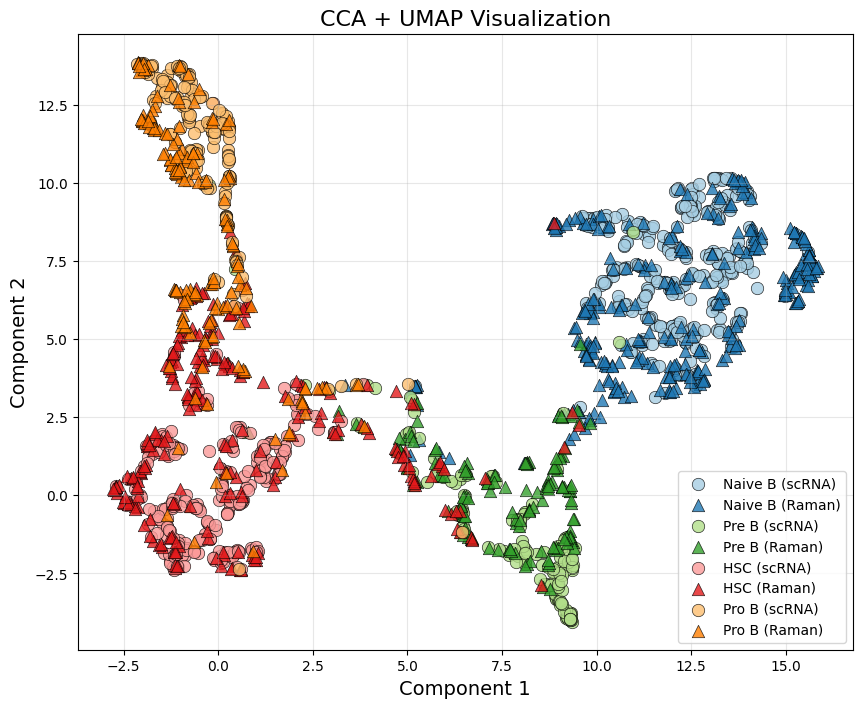

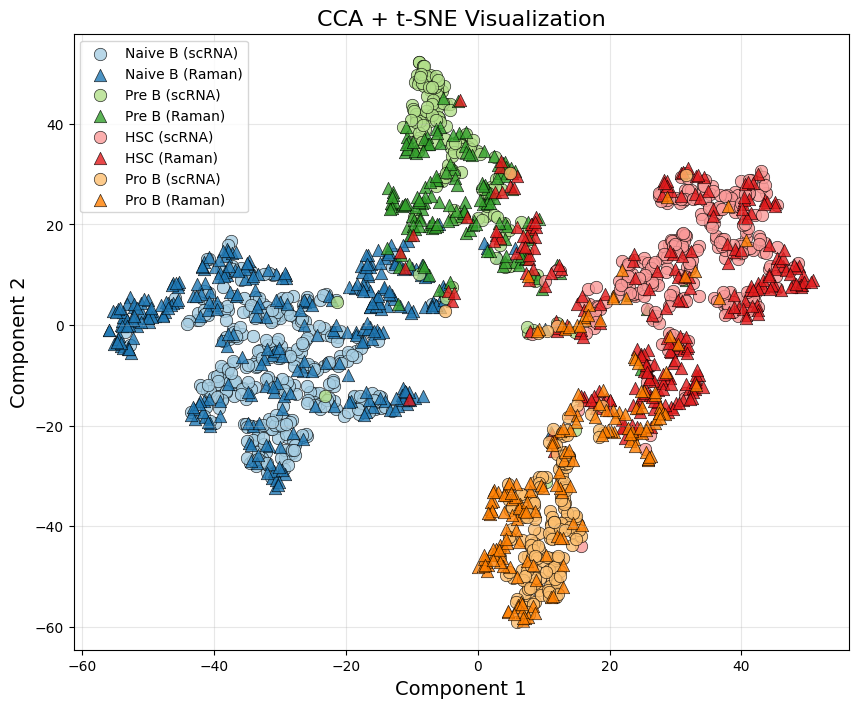

In [19]:
# Example usage:
plot_result(umap_result, "CCA + UMAP Visualization", types, combined_labels, data_sources, "./figures/CCA_integrated_umap.pdf")
plot_result(tsne_result, "CCA + t-SNE Visualization", types, combined_labels, data_sources, "./figures/CCA_integrated_tsne.pdf")


In [69]:
print(scRNA_labels.shape)
print(raman_labels.shape)

(1415,)
(1415,)


In [84]:
import numpy as np

def upsample_and_match(scRNA_pca, raman_pca, scRNA_labels, raman_labels, random_state=None):
    """
    向上抽样使两个数据集的行数一致，然后返回对齐后的数据集和对应标签。
    
    参数:
        scRNA_pca (np.ndarray): 第一个数据集 (n_samples_1, n_features)
        raman_pca (np.ndarray): 第二个数据集 (n_samples_2, n_features)
        scRNA_labels (np.ndarray): 第一个数据集的标签 (n_samples_1,)
        raman_labels (np.ndarray): 第二个数据集的标签 (n_samples_2,)
        random_state (int): 随机种子 (可选)
    
    返回:
        scRNA_pca_resampled (np.ndarray): 对齐后的第一个数据集
        raman_pca_resampled (np.ndarray): 对齐后的第二个数据集
        scRNA_labels_resampled (np.ndarray): 对齐后的第一个数据集的标签
        raman_labels_resampled (np.ndarray): 对齐后的第二个数据集的标签
    """
    np.random.seed(random_state)
    
    # 获取两个数据集的样本数
    n_samples_1 = scRNA_pca.shape[0]
    n_samples_2 = raman_pca.shape[0]
    
    # 判断哪个数据集样本数较少
    if n_samples_1 < n_samples_2:
        # scRNA_pca 需要向上抽样
        indices = np.random.choice(n_samples_1, size=n_samples_2, replace=True)
        scRNA_pca_resampled = scRNA_pca[indices]
        scRNA_labels_resampled = scRNA_labels[indices]
        raman_pca_resampled = raman_pca
        raman_labels_resampled = raman_labels
    else:
        # raman_pca 需要向上抽样
        indices = np.random.choice(n_samples_2, size=n_samples_1, replace=True)
        raman_pca_resampled = raman_pca[indices]
        raman_labels_resampled = raman_labels[indices]
        scRNA_pca_resampled = scRNA_pca
        scRNA_labels_resampled = scRNA_labels
    
    return scRNA_pca_resampled, raman_pca_resampled, scRNA_labels_resampled, raman_labels_resampled


In [86]:
print(scRNA_pca.shape)
raman_pca.shape

(7551, 20)


(1415, 20)

In [92]:
# 调用函数进行向上抽样和对齐
scRNA_pca_resampled, raman_pca_resampled, scRNA_labels_resampled, raman_labels_resampled = upsample_and_match(
    scRNA_pca, raman_pca, scRNA_labels, raman_labels, random_state=42
)

# 打印结果
print("Resampled scRNA_pca shape:", scRNA_pca_resampled.shape)
print("Resampled raman_pca shape:", raman_pca_resampled.shape)
print("Resampled scRNA_labels shape:", scRNA_labels_resampled.shape)
print("Resampled raman_labels shape:", raman_labels_resampled.shape)


Resampled scRNA_pca shape: (7551, 20)
Resampled raman_pca shape: (7551, 20)
Resampled scRNA_labels shape: (7551,)
Resampled raman_labels shape: (7551,)


In [98]:
# 2. CCA 分析
cca = CCA(n_components=2)
scRNA_cca, raman_cca = cca.fit_transform(scRNA_pca_resampled, raman_pca_resampled)

# 3. 合并数据和标签
combined_data = np.vstack([scRNA_cca, raman_cca])
combined_labels = np.concatenate([scRNA_labels_resampled, raman_labels_resampled])
data_sources = np.array(["scRNA"] * len(scRNA_cca) + ["Raman"] * len(raman_cca))

# 4. UMAP 降维
umap = UMAP(n_components=2, random_state=42)
umap_result = umap.fit_transform(combined_data)

# 5. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(combined_data)

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [99]:
combined_labels.shape

(15102,)

In [100]:
umap_result.shape

(15102, 2)

In [77]:
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.manifold import TSNE
from umap import UMAP

# 标准化数据
scRNA_pca_sampled = scRNA_pca
raman_pca_sampled = raman_pca
scRNA_labels_sampled = scRNA_labels
raman_labels_sampled = raman_labels

print(f"""
    scRNA sampled: {scRNA_pca_sampled.shape}
    raman sampled: {raman_pca_sampled.shape}
""")

# 确保特征数一致
min_features = min(scRNA_pca_sampled.shape[1], raman_pca_sampled.shape[1])
scRNA_pca_sampled = scRNA_pca_sampled[:, :min_features]
raman_pca_sampled = raman_pca_sampled[:, :min_features]

# 添加正则化
def add_l2_regularization(X, reg_lambda=0.1):
    """
    在协方差矩阵上添加 L2 正则化。
    """
    cov_matrix = X.T @ X
    n_features = cov_matrix.shape[0]
    regularization = reg_lambda * np.eye(n_features)
    return cov_matrix + regularization

# CCA 分析
cca = CCA(n_components=2)
scRNA_cca, raman_cca = cca.fit_transform(scRNA_pca_sampled, raman_pca_sampled)

# 合并数据和标签
combined_data = np.vstack([scRNA_cca, raman_cca])
combined_labels = np.concatenate([scRNA_labels_sampled, raman_labels_sampled])
data_sources = np.array(["scRNA"] * len(scRNA_cca) + ["Raman"] * len(raman_cca))

# UMAP 降维
umap = UMAP(n_components=2, random_state=42)
umap_result = umap.fit_transform(combined_data)

# t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(combined_data)

print("L2 正则化后的结果计算完成！")



    scRNA sampled: (1415, 20)
    raman sampled: (1415, 20)



g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


L2 正则化后的结果计算完成！


(15102, 4)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_38124\4086700736.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # 自动调整布局以防止内容重叠


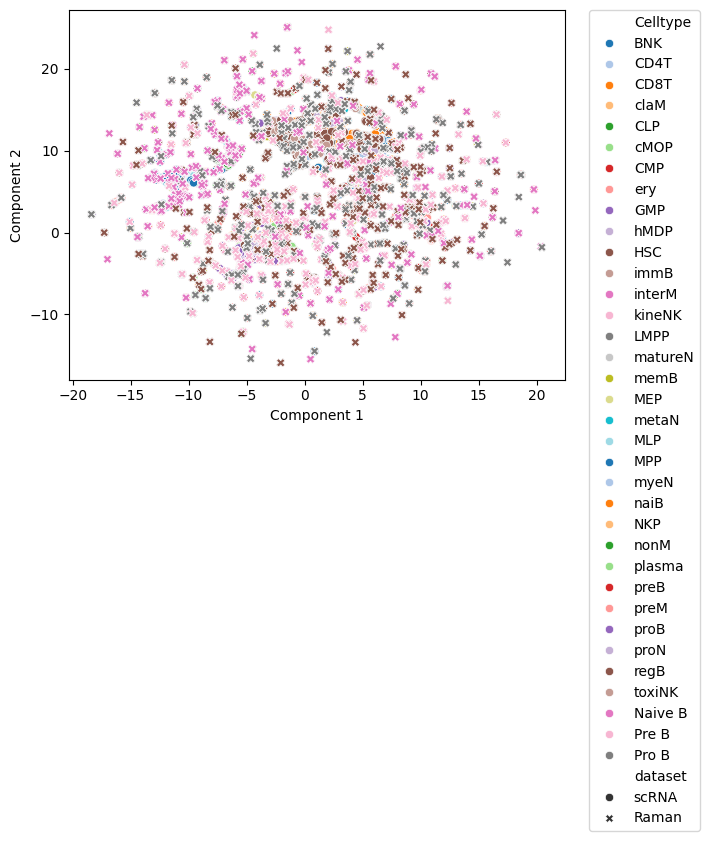

In [101]:
import seaborn as sns
umap_df = pd.DataFrame(umap_result,columns=['X','Y'])
umap_df['Celltype'] = combined_labels
umap_df['dataset'] = result = ['scRNA'] * int(umap_df.shape[0] / 2) + ['Raman'] * int(umap_df.shape[0] / 2)

print(umap_df.shape)
# umap_df.head()
ax = sns.scatterplot(data=umap_df, x='X', y='Y', hue='Celltype', style='dataset',palette='tab20')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.set(xlabel="Component 1",ylabel="Component 2")
plt.tight_layout()  # 自动调整布局以防止内容重叠
plt.show()

(2830, 4)


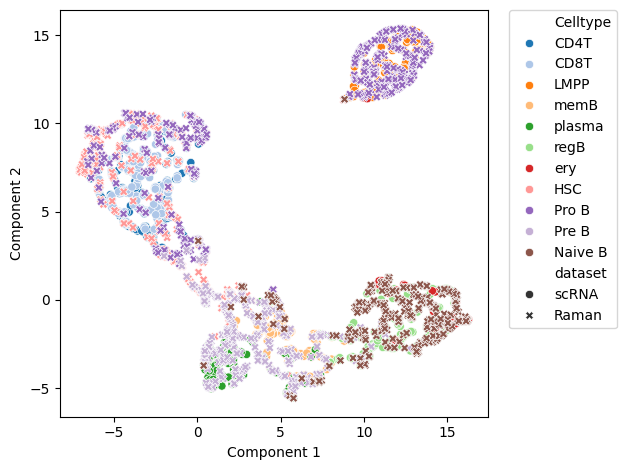

In [75]:
import seaborn as sns
umap_df = pd.DataFrame(umap_result,columns=['X','Y'])
umap_df['Celltype'] = combined_labels
umap_df['dataset'] = result = ['scRNA'] * int(umap_df.shape[0] / 2) + ['Raman'] * int(umap_df.shape[0] / 2)

print(umap_df.shape)
# umap_df.head()
ax = sns.scatterplot(data=umap_df, x='X', y='Y', hue='Celltype', style='dataset',palette='tab20')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.set(xlabel="Component 1",ylabel="Component 2")
plt.tight_layout()  # 自动调整布局以防止内容重叠
plt.show()

In [39]:
# 计算高变基因
# sc.pp.highly_variable_genes(abc_B_ad, flavor='seurat', n_top_genes=None)

# 提取高变基因信息
highly_variable_genes_info = abc_B_ad.var[['highly_variable', 'means', 'dispersions_norm']]

# 按评分（dispersions_norm）排序，选择前100个
top_100_genes = highly_variable_genes_info.sort_values(by='dispersions_norm', ascending=False).head(100)

# 获取前100个高变基因的索引
top_100_gene_names = top_100_genes.index

# 仅保留前100个高变基因
abc_B_ad = abc_B_ad[:, top_100_gene_names]

abc_B_ad


View of AnnData object with n_obs × n_vars = 938 × 100
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [59]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import CCA
from sklearn.utils import resample
from umap import UMAP
from sklearn.manifold import TSNE
import anndata as ad

# 筛选高变基因表达矩阵
highly_variable_mask = abc_B_ad.var['highly_variable']
# highly_variable_genes = abc_B_ad.X
highly_variable_genes = abc_B_ad[:, highly_variable_mask]
print(highly_variable_genes)
# 配对数据
paired_abc_B = []
paired_raman = []

# 确保有相同的细胞类型标记
shared_cell_types = set(highly_variable_genes.obs['cell_type']).intersection(set(raman_adata.obs['cell_type']))

for cell_type in shared_cell_types:
    # 筛选对应细胞类型的单细胞数据和拉曼数据
    abc_B_subset = highly_variable_genes[highly_variable_genes.obs['cell_type'] == cell_type]
    raman_subset = raman_adata[raman_adata.obs['cell_type'] == cell_type]

    # 确保两个数据集都有相同数量的样本
    n_samples = min(abc_B_subset.shape[0], raman_subset.shape[0])

    # 分层抽样
    abc_B_sampled = resample(abc_B_subset.X, n_samples=n_samples, random_state=42)
    raman_sampled = resample(raman_subset.X, n_samples=n_samples, random_state=42)

    # 添加到配对列表
    paired_abc_B.append(abc_B_sampled)
    paired_raman.append(raman_sampled)

# 将配对结果合并
abc_B_paired = np.vstack(paired_abc_B)
raman_paired = np.vstack(paired_raman)

print(abc_B_paired.shape)
print(raman_paired.shape)

View of AnnData object with n_obs × n_vars = 938 × 2000
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
(918, 200

In [63]:
cca = CCA(n_components=3)
cca.fit(abc_B_paired, raman_paired)

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


CCA(n_components=3)

In [64]:
# 进行CCA分析
# n_components = min(abc_B_paired.shape[1], raman_paired.shape[1])  # 保证CCA维度合法
# cca = CCA(n_components=n_components)
# cca.fit(abc_B_paired, raman_paired)

# 获取投影结果
abc_B_cca, raman_cca = cca.transform(abc_B_paired, raman_paired)

# 3. 合并数据和标签
combined_data = np.vstack([abc_B_cca, raman_cca])
combined_labels = np.concatenate([abc_B_ad.obs['cell_type'].values[:len(abc_B_cca)], raman_adata.obs['cell_type'].values[:len(raman_cca)]])
data_sources = np.array(["scRNA"] * len(abc_B_cca) + ["Raman"] * len(raman_cca))

# 4. UMAP 降维
umap = UMAP(n_components=2, random_state=42)
umap_result = umap.fit_transform(combined_data)

# 5. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(combined_data)

# 输出结果
print("CCA, UMAP, and t-SNE analysis complete.")

# 结果对象：
# - abc_B_cca_adata: 单细胞数据的 CCA 投影结果
# - raman_cca_adata: 拉曼数据的 CCA 投影结果
# - umap_result: 合并数据的 UMAP 降维结果
# - tsne_result: 合并数据的 t-SNE 降维结果

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CCA, UMAP, and t-SNE analysis complete.


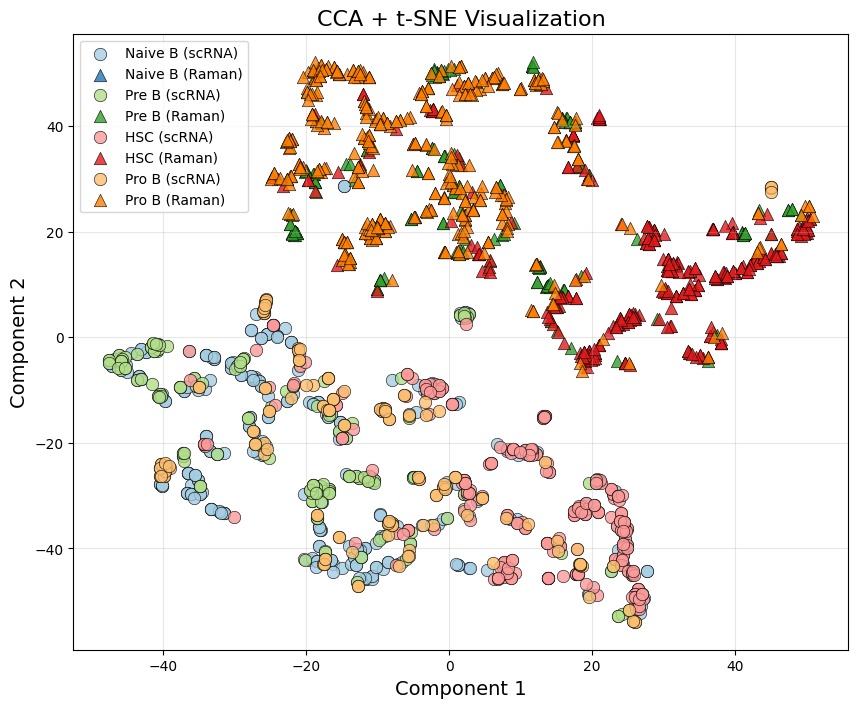

In [65]:
plot_result(tsne_result, "CCA + t-SNE Visualization", types, combined_labels, data_sources, "./figures/CCA_no_PCA_integrated_tsne.pdf")

In [38]:
# disco_ad_pca


scRNA_labels = disco_ad.obs['cell_type'].to_numpy()
raman_labels = raman_adata.obs['cell_type'].to_numpy()

# 1. 确保两数据集每个细胞类型的数量一致
# 找出每种细胞类型的最小样本数
types = set(scRNA_labels) & set(raman_labels)
scRNA_counts = Counter(scRNA_labels)
raman_counts = Counter(raman_labels)
min_counts = {cell_type: min(scRNA_counts[cell_type], raman_counts[cell_type]) for cell_type in types}

# 从每种细胞类型中随机抽样
scRNA_indices = []
raman_indices = []
for cell_type, count in min_counts.items():
    scRNA_indices.extend(np.random.choice(np.where(scRNA_labels == cell_type)[0], count, replace=False))
    raman_indices.extend(np.random.choice(np.where(raman_labels == cell_type)[0], count, replace=False))

scRNA_pca_sampled = disco_ad_pca[scRNA_indices]
raman_pca_sampled = raman_pca[raman_indices]
scRNA_labels_sampled = scRNA_labels[scRNA_indices]
raman_labels_sampled = raman_labels[raman_indices]

print(f"""
    scRNA sampled:{scRNA_pca_sampled.shape}
    raman sampled:{raman_pca_sampled.shape}
    """)



    scRNA sampled:(1415, 20)
    raman sampled:(1415, 20)
    


In [42]:
# 2. CCA 分析
cca = CCA(n_components=2)
scRNA_cca, raman_cca = cca.fit_transform(scRNA_pca_sampled, raman_pca_sampled)

# 3. 合并数据和标签
combined_data = np.vstack([scRNA_cca, raman_cca])
combined_labels = np.concatenate([scRNA_labels_sampled, raman_labels_sampled])
data_sources = np.array(["scRNA"] * len(scRNA_cca) + ["Raman"] * len(raman_cca))

# 4. UMAP 降维
umap = UMAP(n_components=2, random_state=42)
umap_result = umap.fit_transform(combined_data)

# 5. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(combined_data)

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


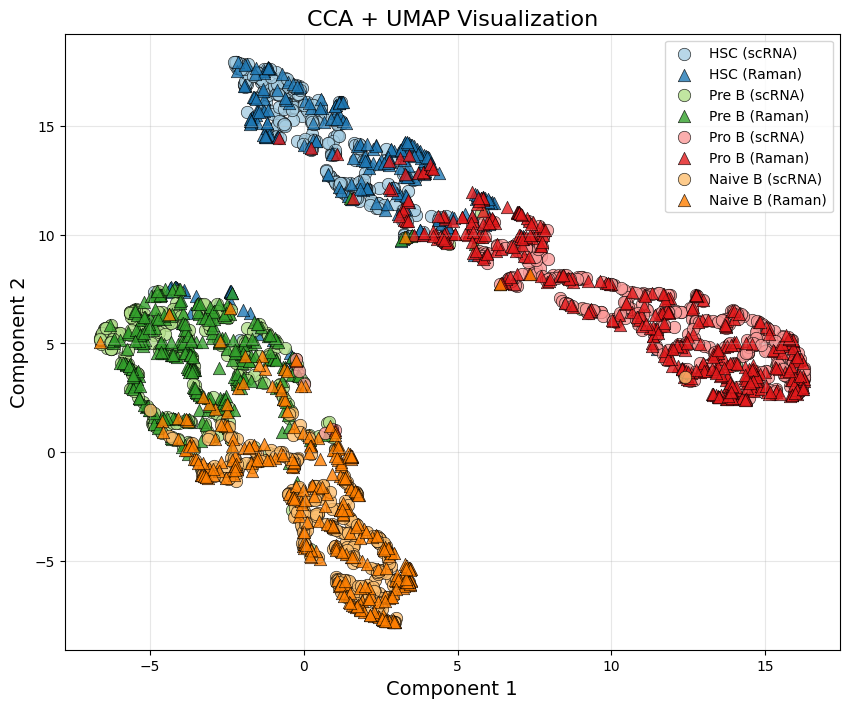

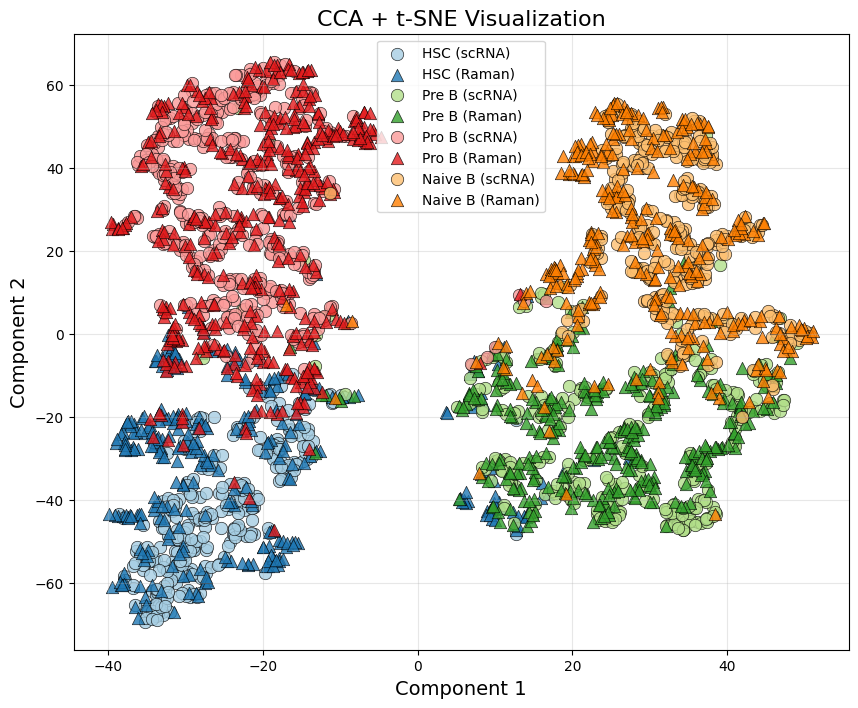

In [43]:
# Example usage:
plot_result(umap_result, "CCA + UMAP Visualization", types, combined_labels, data_sources, "./figures/CCA_dataset2_integrated_umap.pdf")
plot_result(tsne_result, "CCA + t-SNE Visualization", types, combined_labels, data_sources, "./figures/CCA_dataset2_integrated_tsne.pdf")